This file is mainly for analysing the performance of Benders. Structure as follow:
1. Performance Evaluation
2. Analyse Benders Data, more finegrained performance eval

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Evaluate Performance

In [3]:

metrics = [
    # ("upper_bound", "Upper bound"),
    # ("lower_bound", "Lower bound"),
    ("duality_gap", "Duality gap (\%)"),
    ("total_iterations", "Total Iterations"),
    ("exact_iterations", "Exact Iterations"),
    ("inexact_iterations", "Inexact Iterations"),
    ("total_time_master", "Total time master problem (s)"),
    ("total_time_subproblem_exact", "Total time subproblem (exact) (s)"),
    ("total_time_subproblem_pdl", "Total time subproblem (PDL) (s)"),
    ("total_time", "Total time (s)"),
    ("time_per_iteration", "Time per iteration (s)"),
]



def mean_std(series, floatfmt="{:.3f}"):
    return f"{floatfmt.format(series.mean())} ({floatfmt.format(series.std())})"

def make_summary_table(methods, metrics):
    """
    methods: list of (method_name, path) tuples
    metrics: list of (column_name, label) tuples
    """
    method_names = []
    dfs = []

    for method_name, path in methods:
        df = pd.read_csv(path)
        if "duality_gap" not in df.columns:
            df["duality_gap"] = (df["upper_bound"] - df["lower_bound"]) / df["upper_bound"] * 100
        if "time_per_iteration" not in df.columns:
            df["time_per_iteration"] = df["total_time"] / df["total_iterations"].abs()
        method_names.append(method_name)
        dfs.append(df)

    summary = []
    for col, label in metrics:
        row = [label] + [mean_std(df[col]) for df in dfs]
        summary.append(row)

    return pd.DataFrame(summary, columns=["Metric"] + method_names)


## 3 Node

In [ ]:
BASE = "outputs/Benders/3Node"

methods = [
    ("Direct Solve",                  f"{BASE}/Gurobi_Solution.csv"),
    ("Exact Benders",                 f"{BASE}/experiment_data_sample_duration:120_start_exact:True_exact_refinement:False.csv"),
    # ("Exact Midpoint",                f"{BASE}/experiment_data_sample_duration:120_start_exact:True_exact_refinement:False_Exact_InitMidPoint.csv"),
    ("Exact Refinement Baseline",     f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_Baseline.csv"),
    ("Exact Refinement Constrained",  f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstNoLB2.csv"),
    ("Exact Refinement Constrainted Renewable",               f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstNoLBRenewableFlex.csv"),
    ("Exact Refinement Constrainted DualReg0.99 ", f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstraintReg0.99.csv"),
    ("Exact Refinement COnstrained Rewnew10000",f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstRenewUB10000.csv"),
    ("Exact Refinement Constrainted RenewPerc90", f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstRenewPerc90.csv"),
    ("Exact Refinement Constrainted InnerS3L0.99", f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstInnerS3L0.9.csv"),
    ("Exact Refinment Constraint NoClassS3L0.99", f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstNoClassS3L0.99.csv")
    # ("Exact Refine Const Midpoint",   f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstraintNoLB_InitMidPoint.csv"),
    # ("Exact Refine Baseline Midpoint",f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_Baseline_InitMidPoint.csv"),
]

summary_df = make_summary_table(methods, metrics)
latex_table_all = summary_df.to_latex(index=False, escape=False, column_format="lccc")
# print(latex_table_all)
summary_df
# latex_table_all = summary_df.to_latex(index=False, escape=False, column_format="lccc")
# print(latex_table_all)

,Metric,Direct Solve,Exact Benders,Exact Refinement Baseline,Exact Refinement Constrained,Exact Refinement Constrainted Renewable,Exact Refinement Constrainted DualReg0.99,Exact Refinement COnstrained Rewnew10000,Exact Refinement Constrainted RenewPerc90,Exact Refinement Constrainted InnerS3L0.99
0,Duality gap (\%),0.000 (0.000),0.000 (0.000),0.000 (0.000),0.000 (0.000),0.000 (0.000),0.000 (0.000),0.000 (0.000),0.000 (0.000),0.000 (0.000)
1,Total Iterations,1.000 (0.000),74.411 (22.484),76.096 (21.777),70.863 (22.095),76.000 (22.727),71.274 (21.472),73.753 (21.953),71.616 (18.802),78.767 (24.802)
2,Exact Iterations,1.000 (0.000),74.411 (22.484),63.849 (21.366),54.822 (18.353),57.685 (18.496),53.479 (16.540),63.274 (20.840),59.822 (17.813),62.192 (23.587)
3,Inexact Iterations,0.000 (0.000),0.000 (0.000),12.247 (3.467),16.041 (5.494),18.315 (6.762),17.795 (6.137),10.479 (1.916),11.795 (2.339),16.575 (5.592)
4,Total time master problem (s),0.000 (0.000),0.551 (0.296),0.585 (0.299),0.526 (0.271),0.533 (0.282),0.479 (0.248),0.561 (0.279),0.520 (0.237),0.582 (0.345)
5,Total time subproblem (exact) (s),0.000 (0.000),0.657 (0.200),0.641 (0.211),0.564 (0.196),0.549 (0.180),0.508 (0.161),0.629 (0.217),0.590 (0.187),0.588 (0.229)
6,Total time subproblem (PDL) (s),0.000 (0.000),0.000 (0.000),0.013 (0.005),0.020 (0.018),0.018 (0.007),0.019 (0.009),0.013 (0.007),0.012 (0.004),0.015 (0.005)
7,Total time (s),0.092 (0.027),1.208 (0.486),1.238 (0.498),1.109 (0.462),1.100 (0.451),1.007 (0.402),1.203 (0.484),1.122 (0.415),1.185 (0.564)
8,Time per iteration (s),0.092 (0.027),0.016 (0.002),0.016 (0.003),0.015 (0.002),0.014 (0.002),0.014 (0.002),0.016 (0.003),0.015 (0.002),0.014 (0.003)


# Look at Benders Data

## 3 Node

In [9]:
data_path = "data/GEP_data/sample_duration:120_N:B-G-F_G:B2-G2-F2_L:L3.pkl"
bender_data = pd.read_pickle(data_path)


- Benders X is of shape [N, |eq_const| + |ineq_const|]
- 

In [31]:
print(f"Bender x shape: {bender_data.X}")
print(f"Benders T shape: {bender_data.T}")
print(f"Bender eq const: {bender_data.eq_rhs.shape}")
print(f"Benders ineq const: {bender_data.ineq_rhs.shape}")

Bender x shape: tensor([[ 5336.3813, 33061.6701, 51662.9893,  ...,  6838.6144, 43209.3953,
         52853.5000],
        [ 6275.1545, 39737.4963, 48423.8331,  ...,  5921.3997, 38675.5371,
         40707.6715],
        [ 5442.2138, 35031.9978, 36353.5446,  ...,  6770.9992, 45308.5246,
         46002.5236],
        ...,
        [ 5487.2862, 38189.6350, 35797.9839,  ...,  5598.7414, 38248.9856,
         38536.3824],
        [ 4909.2968, 33859.1988, 33862.0980,  ...,  4702.1675, 29877.3126,
         35471.1460],
        [ 4026.5315, 26492.1697, 31276.5590,  ...,  5023.7111, 32573.9884,
         40105.2042]], dtype=torch.float64)
Benders T shape: range(1, 8761)
Bender eq const: torch.Size([73, 360])
Benders ineq const: torch.Size([73, 2886])


# Per instance eval on Benders Performance

In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

def load_method_logs(folder_path):
    """Load all sample CSVs from a method folder into one dataframe."""
    dfs = []
    for fname in os.listdir(folder_path):
        if fname.endswith('.csv'):
            df = pd.read_csv(os.path.join(folder_path, fname))
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def compute_per_instance_stats(df):
    """Compute summary stats per sample."""
    stats = df.groupby('sample').agg(
        total_iters=('iter', 'max'),
        inexact_iters=('exact_mode', lambda x: (~x).sum()),
        exact_iters=('exact_mode', lambda x: x.sum()),
        final_gap=('gap_rel', 'last'),
        # How fast gap closes in first 10 iters
        gap_at_iter5=('gap_rel', lambda x: x.iloc[5] if len(x) > 5 else x.iloc[-1]),
        gap_at_iter10=('gap_rel', lambda x: x.iloc[10] if len(x) > 10 else x.iloc[-1]),
        # Investment properties
        investment=('investment', 'first'),
    ).reset_index()
    return stats

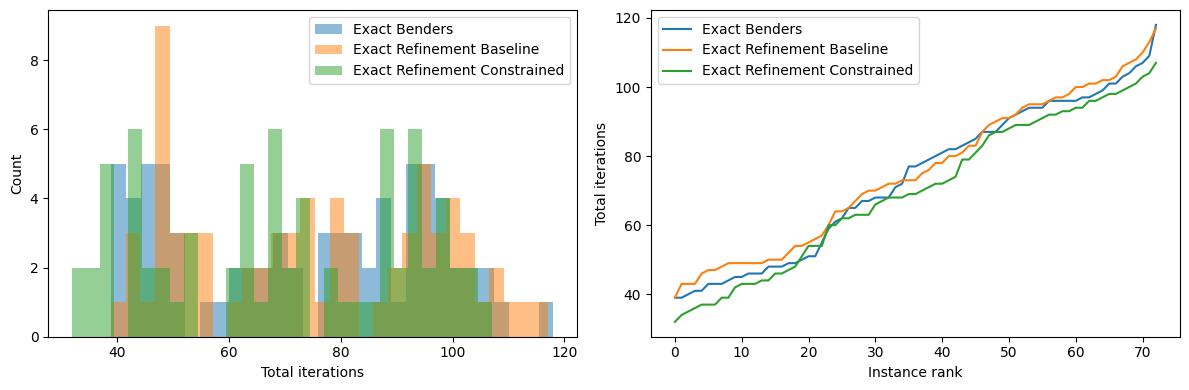

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods = [
    # ("Direct Solve",                  f"{BASE}/Gurobi_Solution.csv"),
    ("Exact Benders",                 f"{BASE}/iter_logs_exact_0"),
    
    # ("Exact Midpoint",                f"{BASE}/experiment_data_sample_duration:120_start_exact:True_exact_refinement:False_Exact_InitMidPoint.csv"),
    ("Exact Refinement Baseline",     f"{BASE}/iter_logs_Inexact_Refine_BendersBaseline"),
    ("Exact Refinement Constrained",  f"{BASE}/iter_logs_inexact_refine_ConstNoLB2"),
    # ("Exact Refinement Constrainted Renewable",               f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstNoLBRenewableFlex.csv"),
    # ("Exact Refinement Constrainted DualReg0.99 ", f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstraintReg0.99.csv"),
    # ("Exact Refinement COnstrained Rewnew10000",f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstRenewUB10000.csv"),
    # ("Exact Refinement Constrainted RenewPerc90", f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstRenewPerc90.csv"),
    # ("Exact Refinement Constrainted InnerS3L0.99", f"{BASE}/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_ConstInnerS3L0.9.csv"),
]


for method_name, folder in methods:
    df = load_method_logs(folder)
    stats = compute_per_instance_stats(df)
    axes[0].hist(stats['total_iters'], bins=30, alpha=0.5, label=method_name)
    axes[1].plot(sorted(stats['total_iters'].values), label=method_name)

axes[0].set_xlabel('Total iterations')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[1].set_xlabel('Instance rank')
axes[1].set_ylabel('Total iterations')
axes[1].legend()
plt.tight_layout()

Text(0.5, 1.0, 'Gap convergence trajectory')

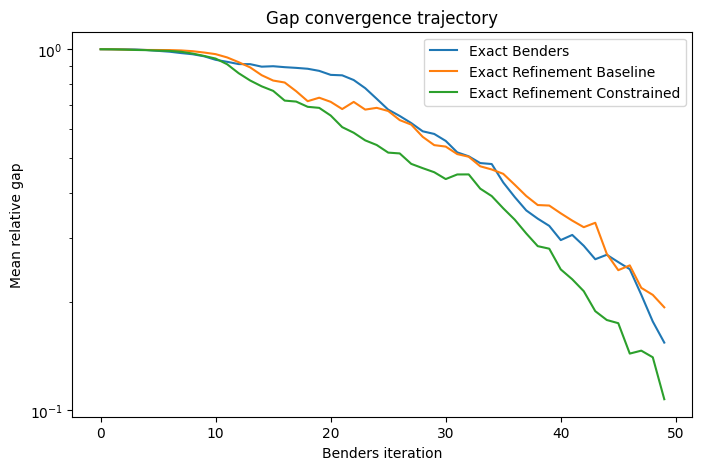

In [19]:
def mean_gap_trajectory(df, max_iter=50):
    """Average gap at each iteration across all samples."""
    trajectories = []
    for sample, group in df.groupby('sample'):
        gap = group.sort_values('iter')['gap_rel'].values
        # Pad to max_iter with final value
        padded = np.pad(gap, (0, max(0, max_iter - len(gap))), 
                       mode='edge')[:max_iter]
        trajectories.append(padded)
    return np.mean(trajectories, axis=0)

plt.figure(figsize=(8, 5))
for method_name, folder in methods:
    df = load_method_logs(folder)
    traj = mean_gap_trajectory(df)
    plt.plot(traj, label=method_name)

plt.xlabel('Benders iteration')
plt.ylabel('Mean relative gap')
plt.yscale('log')
plt.legend()
plt.title('Gap convergence trajectory')

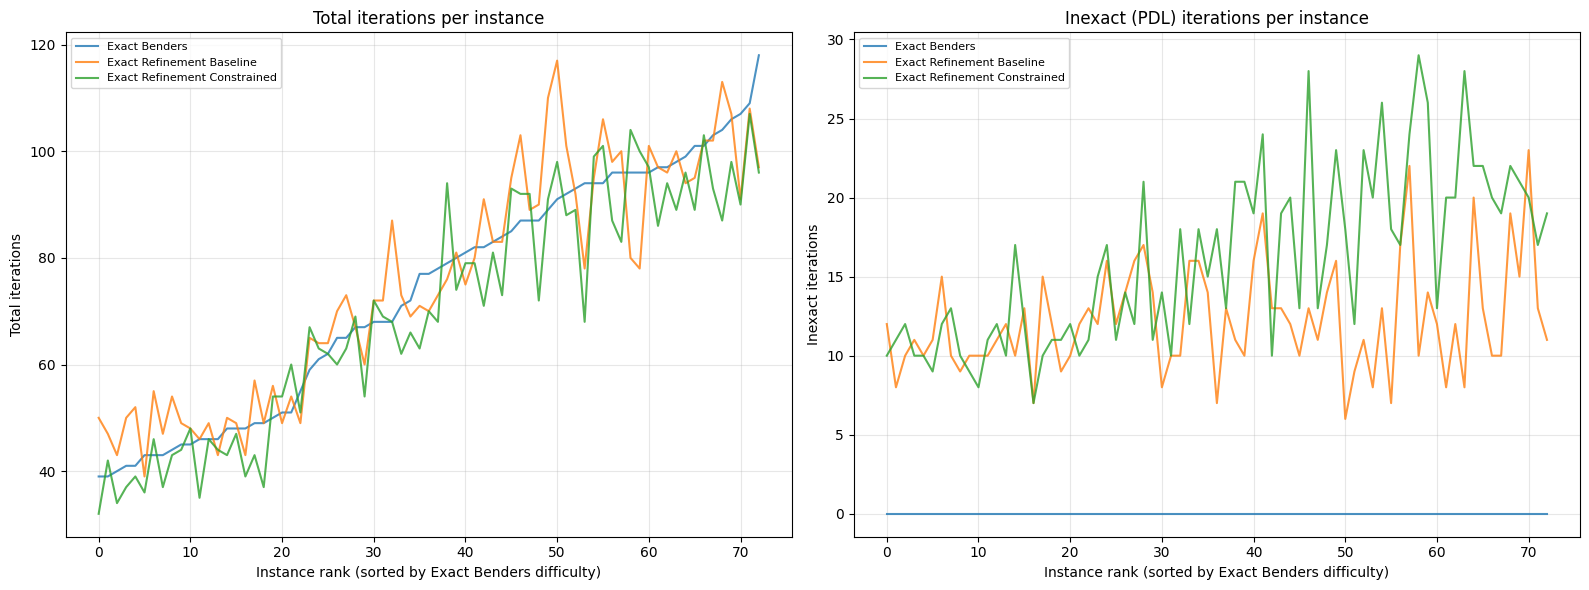

In [20]:
# Load all methods
all_stats = {}
for method_name, folder in methods:
    df = load_method_logs(folder)
    all_stats[method_name] = compute_per_instance_stats(df)

# Sort order based on first method's total iters
first_method = methods[0][0]
base_stats = all_stats[first_method].set_index('sample')
sort_order = base_stats['total_iters'].argsort().values
sorted_samples = base_stats.index.values[sort_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for method_name, _ in methods:
    stats = all_stats[method_name].set_index('sample').loc[sorted_samples]
    axes[0].plot(stats['total_iters'].values, label=method_name, alpha=0.8)
    axes[1].plot(stats['inexact_iters'].values, label=method_name, alpha=0.8)

for ax, title, ylabel in zip(axes,
    ['Total iterations per instance', 'Inexact (PDL) iterations per instance'],
    ['Total iterations', 'Inexact iterations']):
    ax.set_xlabel(f'Instance rank (sorted by {first_method} difficulty)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Correlation: generator investment vs total iterations
  Generator 0: nan
  Generator 1: nan
  Generator 2: nan
  Generator 3: nan
  Generator 4: nan
  Generator 5: nan

Total investment vs iterations: nan
Zero generators vs iterations:  nan
Max single generator vs iters:  nan


/Users/peterhuang/miniconda3/envs/env/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/peterhuang/miniconda3/envs/env/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/peterhuang/miniconda3/envs/env/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/peterhuang/miniconda3/envs/env/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


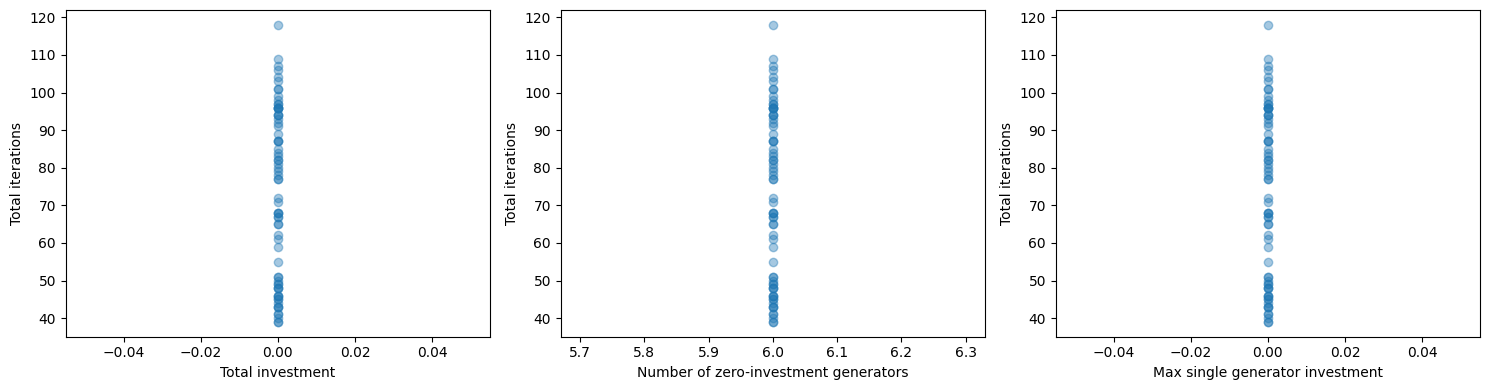

In [21]:
import ast

def parse_investment(inv_str):
    """Parse investment string like '[-0.0, 327.0, ...]' to array."""
    return np.array(ast.literal_eval(inv_str))

# Use one method's stats as reference
ref_stats = all_stats['Exact Benders'].copy()
ref_stats['inv_parsed'] = ref_stats['investment'].apply(parse_investment)

n_generators = len(ref_stats['inv_parsed'].iloc[0])

# Expand investment into per-generator columns
for g in range(n_generators):
    ref_stats[f'gen_{g}'] = ref_stats['inv_parsed'].apply(lambda x: x[g])

# Correlate each generator's investment with total iterations
print("Correlation: generator investment vs total iterations")
for g in range(n_generators):
    corr = ref_stats[f'gen_{g}'].corr(ref_stats['total_iters'])
    print(f"  Generator {g}: {corr:.3f}")

# Also check total investment and sparsity
ref_stats['total_investment'] = ref_stats['inv_parsed'].apply(np.sum)
ref_stats['n_zero_gens'] = ref_stats['inv_parsed'].apply(lambda x: (x == 0).sum())
ref_stats['max_gen'] = ref_stats['inv_parsed'].apply(np.max)

print(f"\nTotal investment vs iterations: {ref_stats['total_investment'].corr(ref_stats['total_iters']):.3f}")
print(f"Zero generators vs iterations:  {ref_stats['n_zero_gens'].corr(ref_stats['total_iters']):.3f}")
print(f"Max single generator vs iters:  {ref_stats['max_gen'].corr(ref_stats['total_iters']):.3f}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(ref_stats['total_investment'], ref_stats['total_iters'], alpha=0.4)
axes[0].set_xlabel('Total investment')
axes[0].set_ylabel('Total iterations')

axes[1].scatter(ref_stats['n_zero_gens'], ref_stats['total_iters'], alpha=0.4)
axes[1].set_xlabel('Number of zero-investment generators')
axes[1].set_ylabel('Total iterations')

axes[2].scatter(ref_stats['max_gen'], ref_stats['total_iters'], alpha=0.4)
axes[2].set_xlabel('Max single generator investment')
axes[2].set_ylabel('Total iterations')

plt.tight_layout()
plt.show()

Total demand vs iterations:    -0.755
Peak demand vs iterations:     -0.775
Demand variability vs iters:   -0.744


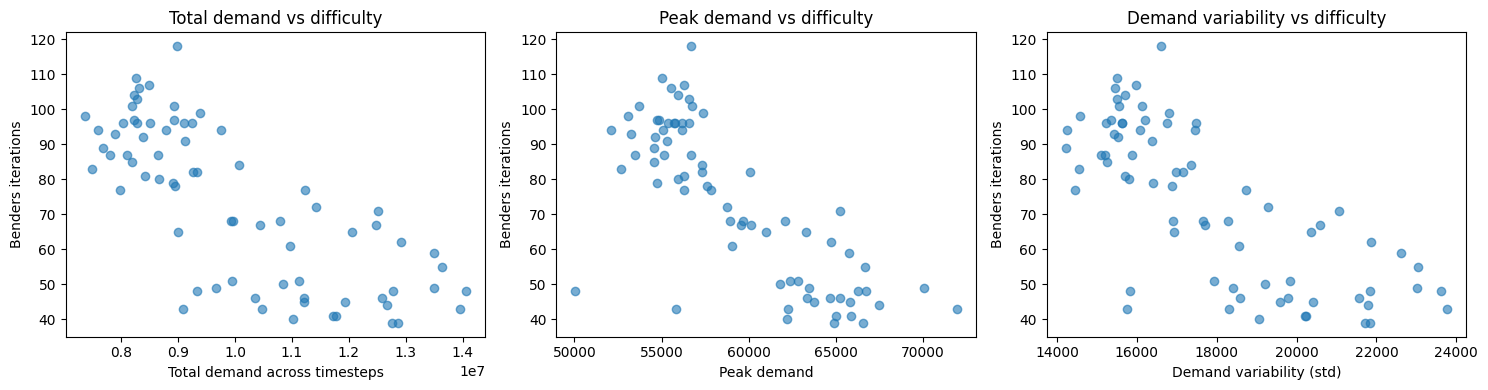

In [34]:
# Load bender_data
data_path = "data/GEP_data/sample_duration:120_N:B-G-F_G:B2-G2-F2_L:L3.pkl"
bender_data = pd.read_pickle(data_path)

X = bender_data.X.numpy()  # [73, 3246]
n_samples = X.shape[0]

# From GEPProblemSet structure:
# First neq columns = eq_rhs = demand per node per timestep
# Remaining = ineq_rhs = capacity bounds, flow limits

neq = bender_data.neq  # n_nodes * sample_duration
n_nodes = bender_data.num_n
n_gens = bender_data.num_g
n_lines = bender_data.num_l

# Extract demand — first neq columns
demand = X[:, :neq]  # [73, neq]

# Summarise demand per sample
total_demand = demand.sum(axis=1)       # total demand across all nodes/timesteps
max_demand = demand.max(axis=1)         # peak demand
demand_std = demand.std(axis=1)         # demand variability

# Get total_iters per sample from Exact Benders stats
ref_stats = all_stats['Exact Benders'].set_index('sample')
total_iters = ref_stats['total_iters'].values  # [73]

# Correlate
print(f"Total demand vs iterations:    {np.corrcoef(total_demand, total_iters)[0,1]:.3f}")
print(f"Peak demand vs iterations:     {np.corrcoef(max_demand, total_iters)[0,1]:.3f}")
print(f"Demand variability vs iters:   {np.corrcoef(demand_std, total_iters)[0,1]:.3f}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(total_demand, total_iters, alpha=0.6)
axes[0].set_xlabel('Total demand across timesteps')
axes[0].set_ylabel('Benders iterations')
axes[0].set_title('Total demand vs difficulty')

axes[1].scatter(max_demand, total_iters, alpha=0.6)
axes[1].set_xlabel('Peak demand')
axes[1].set_ylabel('Benders iterations')
axes[1].set_title('Peak demand vs difficulty')

axes[2].scatter(demand_std, total_iters, alpha=0.6)
axes[2].set_xlabel('Demand variability (std)')
axes[2].set_ylabel('Benders iterations')
axes[2].set_title('Demand variability vs difficulty')

plt.tight_layout()
plt.show()


Exact Benders
  Total demand vs iterations:  -0.755
  Peak demand vs iterations:   -0.775
  Demand variability vs iters: -0.744

Exact Refinement Baseline
  Total demand vs iterations:  -0.754
  Peak demand vs iterations:   -0.746
  Demand variability vs iters: -0.748

Exact Refinement Constrained
  Total demand vs iterations:  -0.756
  Peak demand vs iterations:   -0.767
  Demand variability vs iters: -0.747


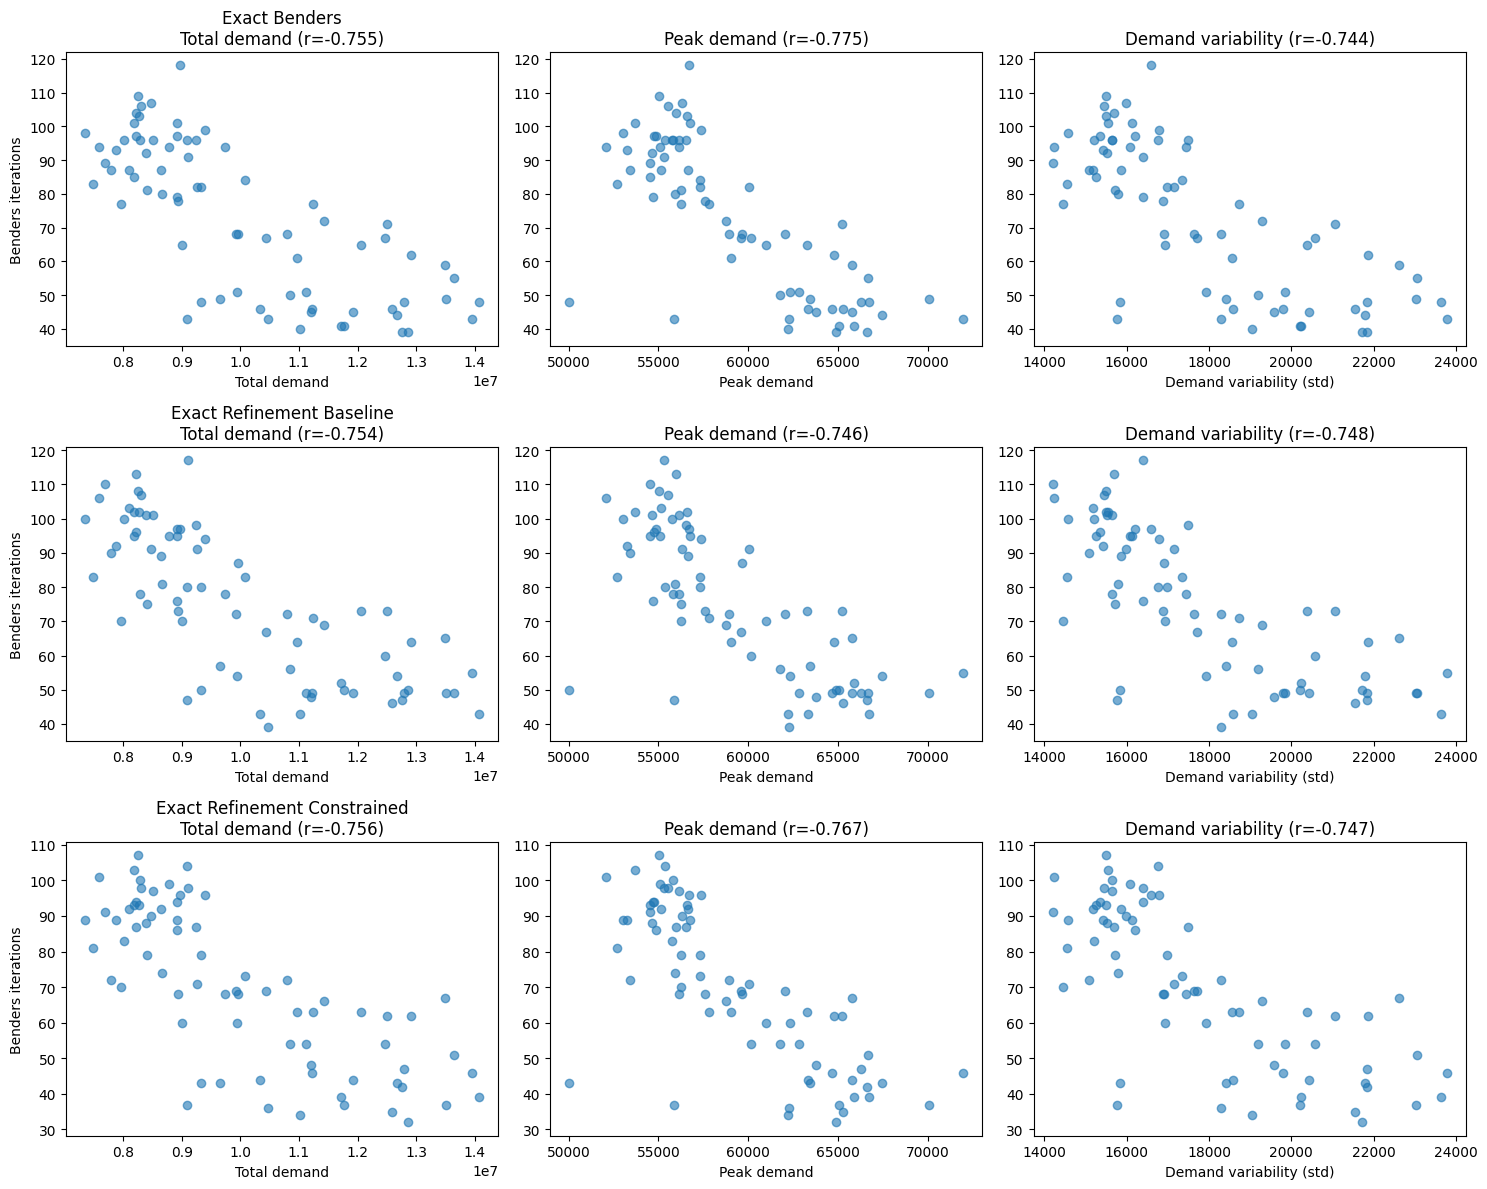

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

pdl_methods = ['Exact Benders', 'Exact Refinement Baseline', 'Exact Refinement Constrained']

for row, method_name in enumerate(pdl_methods):
    stats = all_stats[method_name].set_index('sample')
    total_iters = stats['total_iters'].values

    corr_total = np.corrcoef(total_demand, total_iters)[0,1]
    corr_peak  = np.corrcoef(max_demand, total_iters)[0,1]
    corr_std   = np.corrcoef(demand_std, total_iters)[0,1]

    print(f"\n{method_name}")
    print(f"  Total demand vs iterations:  {corr_total:.3f}")
    print(f"  Peak demand vs iterations:   {corr_peak:.3f}")
    print(f"  Demand variability vs iters: {corr_std:.3f}")

    axes[row, 0].scatter(total_demand, total_iters, alpha=0.6)
    axes[row, 0].set_xlabel('Total demand')
    axes[row, 0].set_ylabel('Benders iterations')
    axes[row, 0].set_title(f'{method_name}\nTotal demand (r={corr_total:.3f})')

    axes[row, 1].scatter(max_demand, total_iters, alpha=0.6)
    axes[row, 1].set_xlabel('Peak demand')
    axes[row, 1].set_title(f'Peak demand (r={corr_peak:.3f})')

    axes[row, 2].scatter(demand_std, total_iters, alpha=0.6)
    axes[row, 2].set_xlabel('Demand variability (std)')
    axes[row, 2].set_title(f'Demand variability (r={corr_std:.3f})')

plt.tight_layout()
plt.show()

In [36]:
# Find instances where PDL is worse than Exact Benders
exact_iters = all_stats['Exact Benders'].set_index('sample')['total_iters']
baseline_iters = all_stats['Exact Refinement Baseline'].set_index('sample')['total_iters']
constrained_iters = all_stats['Exact Refinement Constrained'].set_index('sample')['total_iters']

diff_baseline = baseline_iters - exact_iters
diff_constrained = constrained_iters - exact_iters

print(f"Baseline worse than Exact Benders: {(diff_baseline > 0).sum()} / {len(diff_baseline)} instances")
print(f"Constrained worse than Exact Benders: {(diff_constrained > 0).sum()} / {len(diff_constrained)} instances")
print(f"\nBaseline mean diff: {diff_baseline.mean():.1f} iters")
print(f"Constrained mean diff: {diff_constrained.mean():.1f} iters")

# What demand level are the bad instances?
bad_baseline = diff_baseline[diff_baseline > 0].index
bad_constrained = diff_constrained[diff_constrained > 0].index

print(f"\nMean total demand — bad baseline instances:    {total_demand[bad_baseline].mean():.0f}")
print(f"Mean total demand — all instances:             {total_demand.mean():.0f}")
print(f"Mean total demand — bad constrained instances: {total_demand[bad_constrained].mean():.0f}")

Baseline worse than Exact Benders: 43 / 73 instances
Constrained worse than Exact Benders: 23 / 73 instances

Baseline mean diff: 1.7 iters
Constrained mean diff: -3.5 iters

Mean total demand — bad baseline instances:    10104216
Mean total demand — all instances:             10018494
Mean total demand — bad constrained instances: 9850414


Constrained better than Baseline: 56 / 73 instances
Constrained worse than Baseline:  14 / 73 instances
Equal:                            3 / 73 instances

Mean iteration difference (Constrained - Baseline): -5.2
Median iteration difference:                        -5.0
Max improvement (Constrained better by):            26 iters
Max degradation (Constrained worse by):             24 iters

Mean total demand — Constrained better: 10047840
Mean total demand — Constrained worse:  9906791
Mean total demand — all instances:      10018494


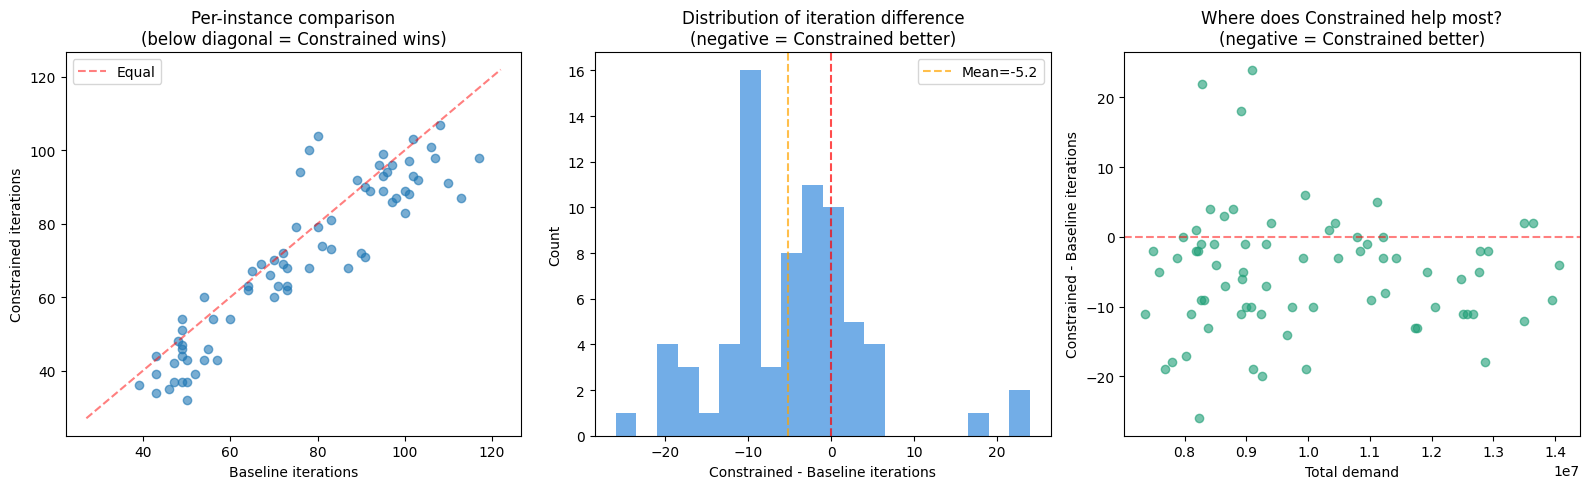

In [37]:
diff = constrained_iters - baseline_iters

print(f"Constrained better than Baseline: {(diff < 0).sum()} / {len(diff)} instances")
print(f"Constrained worse than Baseline:  {(diff > 0).sum()} / {len(diff)} instances")
print(f"Equal:                            {(diff == 0).sum()} / {len(diff)} instances")
print(f"\nMean iteration difference (Constrained - Baseline): {diff.mean():.1f}")
print(f"Median iteration difference:                        {diff.median():.1f}")
print(f"Max improvement (Constrained better by):            {(-diff).max():.0f} iters")
print(f"Max degradation (Constrained worse by):             {diff.max():.0f} iters")

# What demand level are instances where Constrained wins/loses?
better = diff[diff < 0].index
worse = diff[diff > 0].index

print(f"\nMean total demand — Constrained better: {total_demand[better].mean():.0f}")
print(f"Mean total demand — Constrained worse:  {total_demand[worse].mean():.0f}")
print(f"Mean total demand — all instances:      {total_demand.mean():.0f}")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: instance-by-instance direct comparison
axes[0].scatter(baseline_iters, constrained_iters, alpha=0.6)
lims = [min(baseline_iters.min(), constrained_iters.min()) - 5,
        max(baseline_iters.max(), constrained_iters.max()) + 5]
axes[0].plot(lims, lims, 'r--', alpha=0.5, label='Equal')
axes[0].set_xlabel('Baseline iterations')
axes[0].set_ylabel('Constrained iterations')
axes[0].set_title('Per-instance comparison\n(below diagonal = Constrained wins)')
axes[0].legend()

# Histogram of differences
axes[1].hist(diff.values, bins=20, alpha=0.7, color='#378ADD')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].axvline(diff.mean(), color='orange', linestyle='--', alpha=0.7, label=f'Mean={diff.mean():.1f}')
axes[1].set_xlabel('Constrained - Baseline iterations')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of iteration difference\n(negative = Constrained better)')
axes[1].legend()

# Difference vs demand level
axes[2].scatter(total_demand, diff.values, alpha=0.6, color='#1D9E75')
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Total demand')
axes[2].set_ylabel('Constrained - Baseline iterations')
axes[2].set_title('Where does Constrained help most?\n(negative = Constrained better)')

plt.tight_layout()
plt.show()